In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

In [2]:
def problem1_estimate(n):
    """Estimate the integral using n samples"""
    #Generate n uniform random samples on [0,1]
    U = np.random.uniform(0, 1, n)
    
    #Evaluate the function at each sample
    f_values = (1 - U**2)**(3/2)
    
    #Compute the sample mean (b-a = 1, so we don't multiply)
    estimate = np.mean(f_values)
    
    return estimate

In [3]:
#Test with different sample sizes
sample_sizes = [100, 1000, 10000, 100000]
print("Problem 1.1")
for n in sample_sizes:
    est = problem1_estimate(n)
    print(f"n = {n:6d}: estimate = {est:.6f}")

Problem 1.1
n =    100: estimate = 0.618604
n =   1000: estimate = 0.591347
n =  10000: estimate = 0.594542
n = 100000: estimate = 0.588869


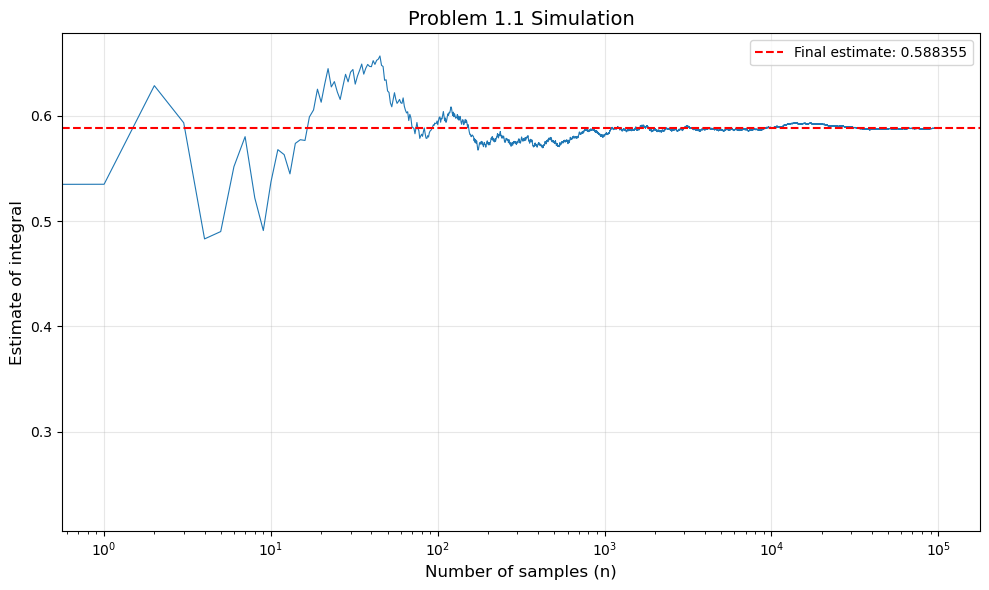

In [4]:
n_max = 100000
U = np.random.uniform(0, 1, n_max)
f_values = (1 - U**2)**(3/2)

#Compute running average
running_avg = np.cumsum(f_values) / np.arange(1, n_max + 1)

#plot running average against sample size
plt.figure(figsize=(10, 6))
plt.plot(running_avg, linewidth=0.8)
plt.axhline(y=running_avg[-1], color='r', linestyle='--', 
            label=f'Final estimate: {running_avg[-1]:.6f}')
plt.xlabel('Number of samples (n)', fontsize=12)
plt.ylabel('Estimate of integral', fontsize=12)
plt.title('Problem 1.1 Simulation', fontsize=14)
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('problem1_convergence.png', dpi=300)
plt.show()

Problem 1.2: ∫₀^∞ ∫₀^x e^(-(x+y)) dy dx

Estimates for different sample sizes:
n =    100: estimate = 0.497077, error = 0.002923
n =   1000: estimate = 0.499786, error = 0.000214
n =  10000: estimate = 0.496394, error = 0.003606
n = 100000: estimate = 0.499742, error = 0.000258

Generating convergence plot...


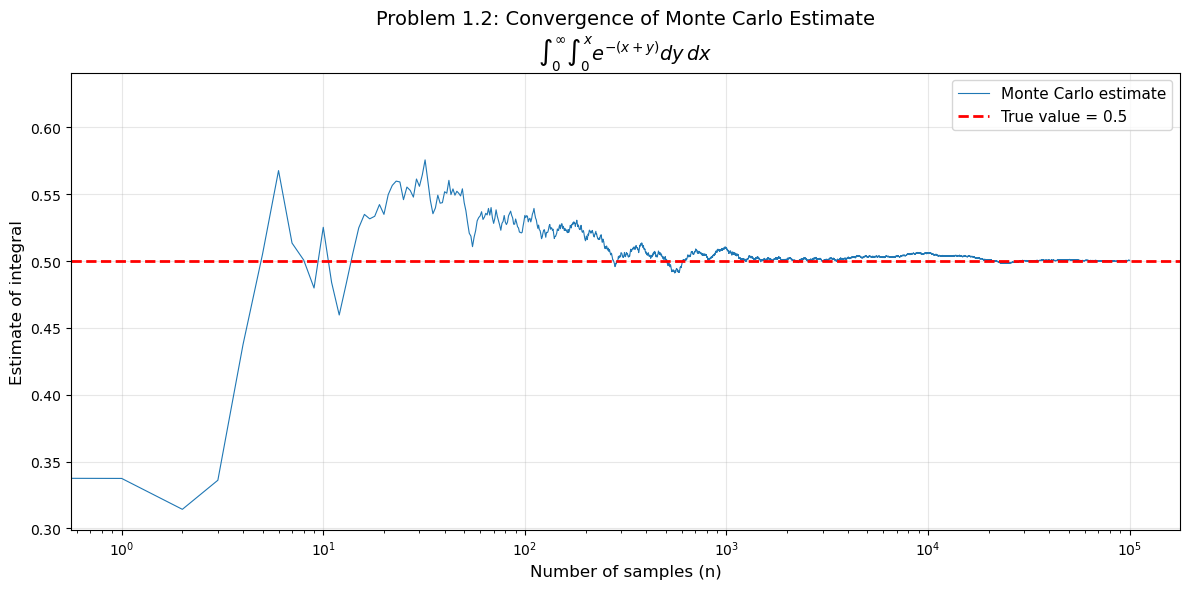


True value: 0.5
Final estimate: 0.500512
Final error: 0.000512


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ==================== PROBLEM 1.2 (Simple Approach) ====================
print("Problem 1.2: ∫₀^∞ ∫₀^x e^(-(x+y)) dy dx")
print("="*60)

# True value
true_value = 1/2

def estimate_double_integral_simple(n_samples):
    """
    After solving inner integral: ∫₀^∞ e^(-x)(1 - e^(-x)) dx
    
    Method:
    1. Generate U ~ Uniform(0,1)
    2. Transform to X = -ln(U), which gives X ~ Exponential(1)
    3. Evaluate function at X
    4. Average
    
    This works because:
    ∫₀^∞ f(x)e^(-x) dx = E[f(X)] where X ~ Exponential(1)
    """
    # Generate uniform random variables
    U = np.random.uniform(0, 1, n_samples)
    
    # Transform to exponential
    X = -np.log(U)
    
    # Evaluate the function (1 - e^(-x))
    function_values = 1 - np.exp(-X)
    
    # Estimate the integral
    estimate = np.mean(function_values)
    
    return estimate

# Test with different sample sizes
sample_sizes = [100, 1000, 10000, 100000]
print("\nEstimates for different sample sizes:")
for n in sample_sizes:
    est = estimate_double_integral_simple(n)
    error = abs(est - true_value)
    print(f"n = {n:6d}: estimate = {est:.6f}, error = {error:.6f}")

# ==================== CONVERGENCE PLOT ====================
print("\nGenerating convergence plot...")

n_max = 100000
np.random.seed(42)

# Generate uniform samples
U = np.random.uniform(0, 1, n_max)

# Transform to exponential
X = -np.log(U)

# Evaluate function
function_values = 1 - np.exp(-X)

# Compute running average
running_avg = np.cumsum(function_values) / np.arange(1, n_max + 1)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(running_avg, linewidth=0.8, label='Monte Carlo estimate')
plt.axhline(y=true_value, color='r', linestyle='--', linewidth=2,
            label=f'True value = {true_value}')
plt.xlabel('Number of samples (n)', fontsize=12)
plt.ylabel('Estimate of integral', fontsize=12)
plt.title('Problem 1.2: Convergence of Monte Carlo Estimate\n' + 
          r'$\int_0^\infty \int_0^x e^{-(x+y)} dy\, dx$', fontsize=14)
plt.xscale('log')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('problem1_2_convergence.png', dpi=300)
plt.show()

print(f"\nTrue value: {true_value}")
print(f"Final estimate: {running_avg[-1]:.6f}")
print(f"Final error: {abs(running_avg[-1] - true_value):.6f}")